In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Step 1: Load and stack acceleration data ===
filenames = ['N001_020.csv', 'N002_020.csv', 'N003_020.csv', 'N004_020.csv']
data_list = []

for file in filenames:
    df = pd.read_csv(file)
    acc = df.iloc[:, 1:4].values  # Extract columns 2-4: acceleration X, Y, Z
    data_list.append(acc)

free_vib_wsn = np.hstack(data_list)  # Shape: (samples, 12)
np.save('free_vib_wsn.npy', free_vib_wsn)
print(f"[Saved] free_vib_wsn.npy with shape {free_vib_wsn.shape}")



[Saved] free_vib_wsn.npy with shape (17999, 12)


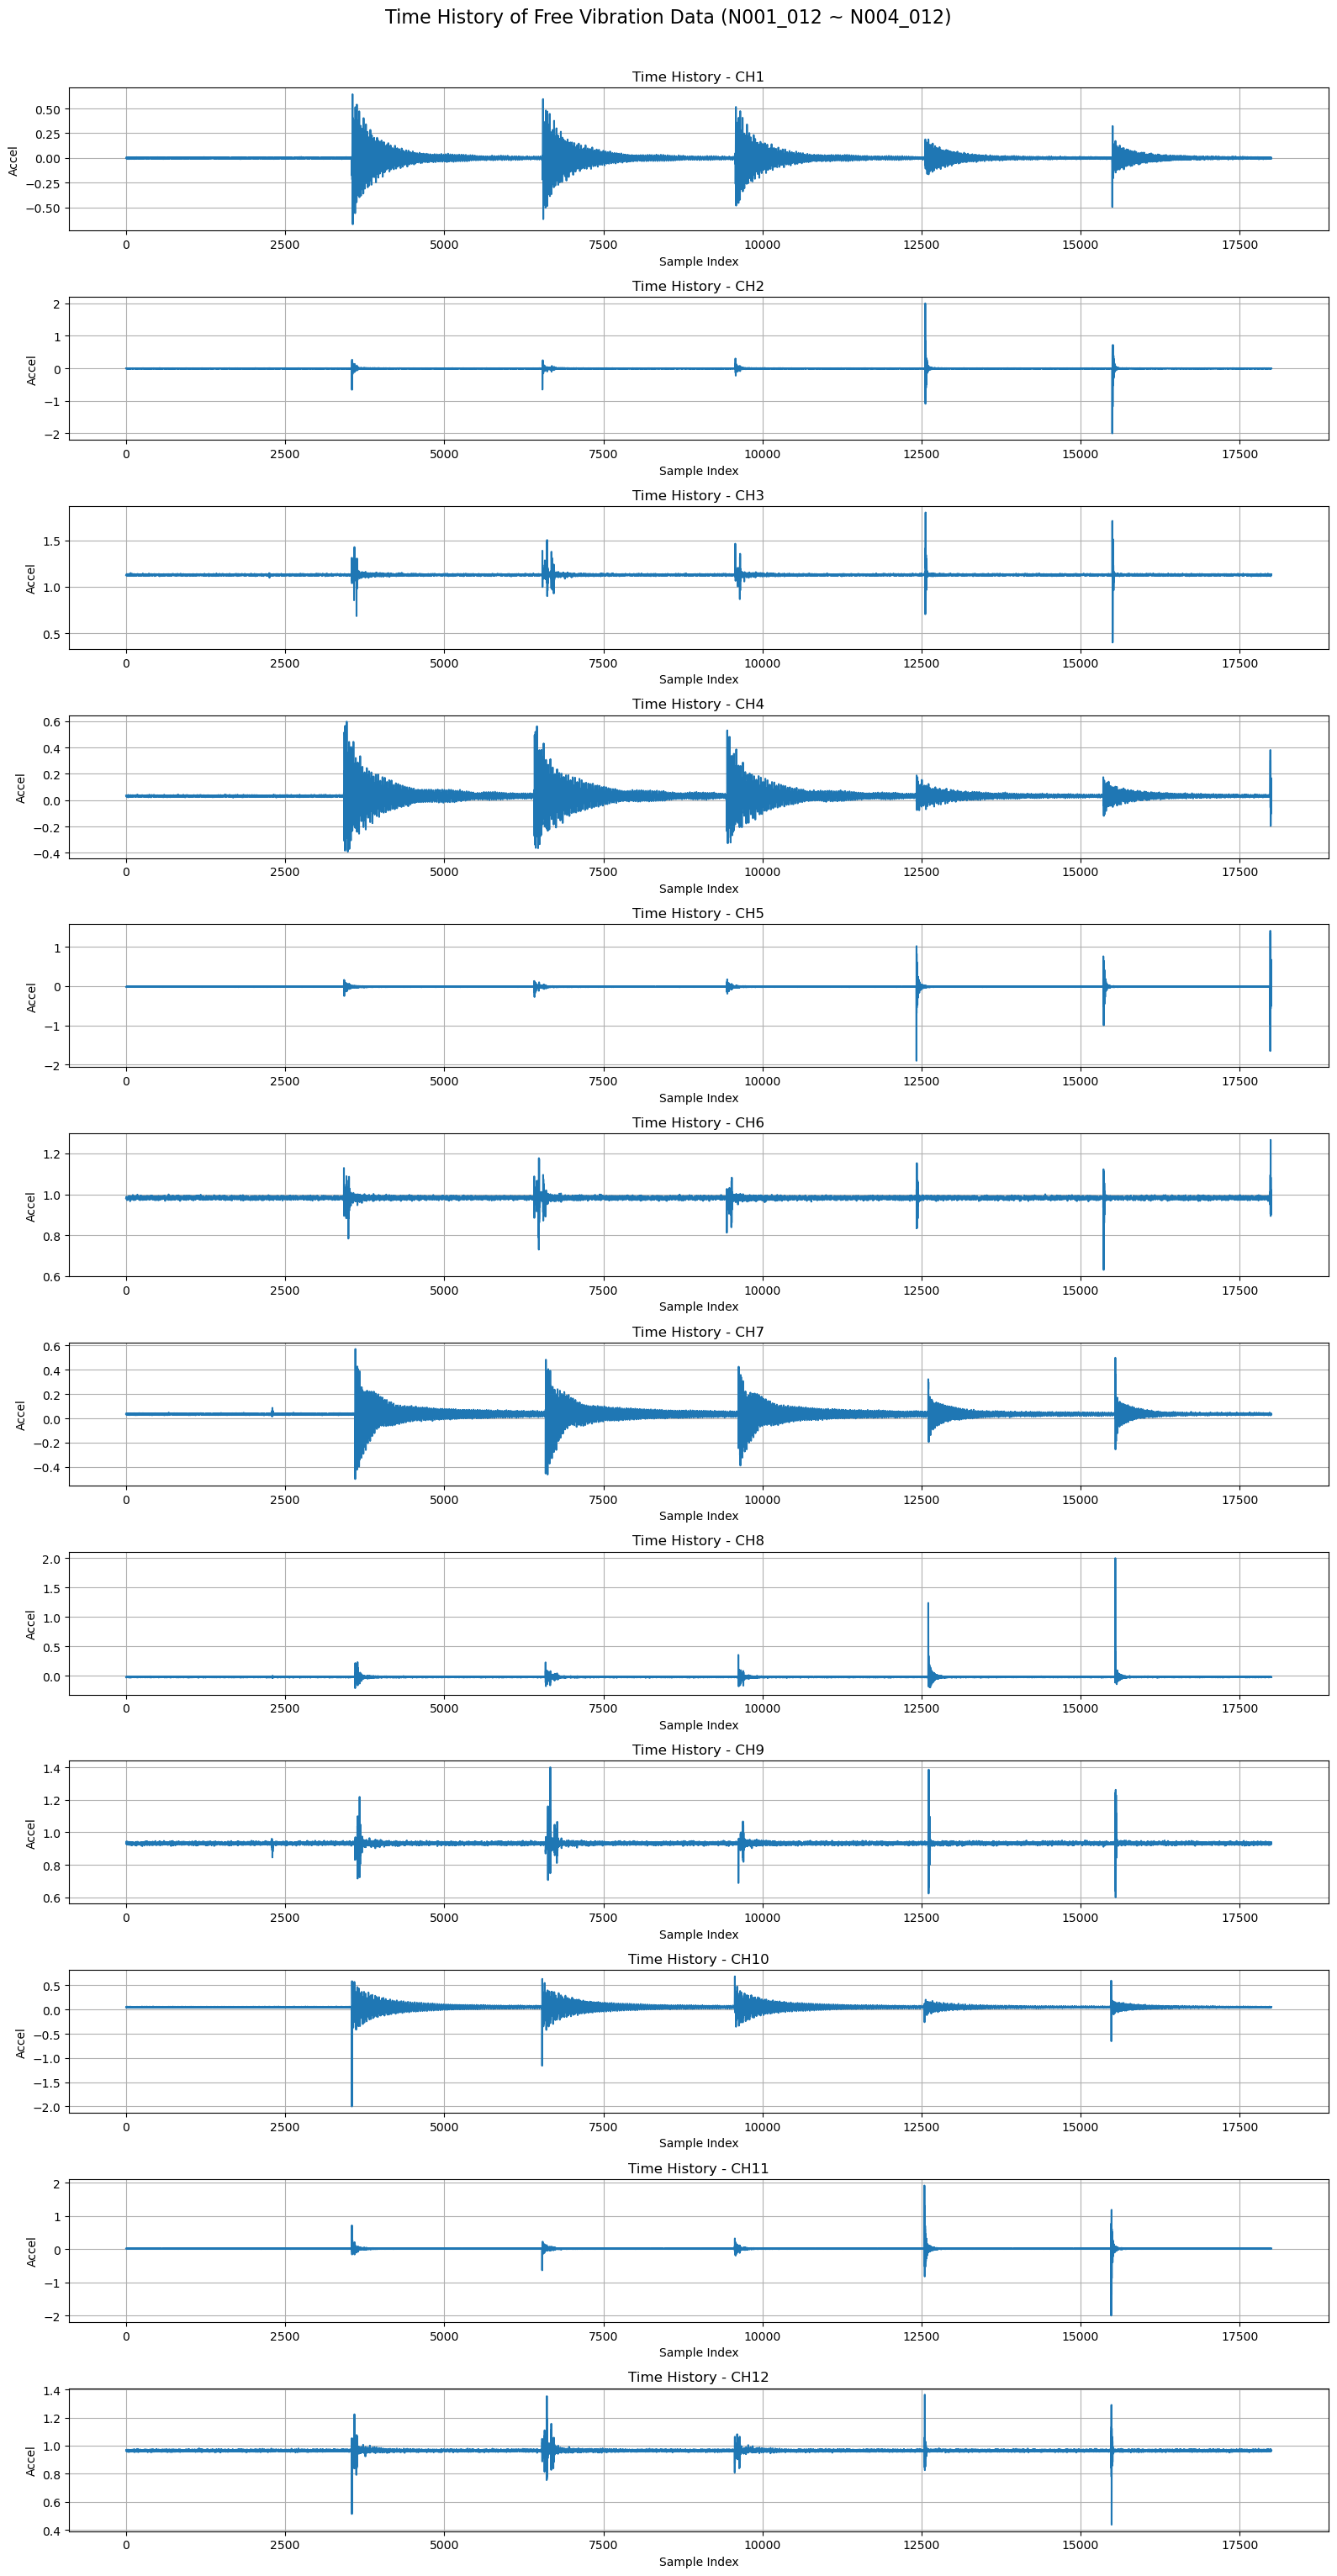

In [2]:
# === Step 2: Plot time-history curves ===
plt.figure(figsize=(16, 30))
n_channels = free_vib_wsn.shape[1]
time = np.arange(free_vib_wsn.shape[0])  # sample index

for i in range(n_channels):
    plt.subplot(12, 1, i + 1)
    plt.plot(time, free_vib_wsn[:, i])
    plt.title(f"Time History - CH{i+1}")
    plt.xlabel("Sample Index")
    plt.ylabel("Accel")
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Time History of Free Vibration Data (N001_012 ~ N004_012)", fontsize=16, y=1.02)
plt.show()



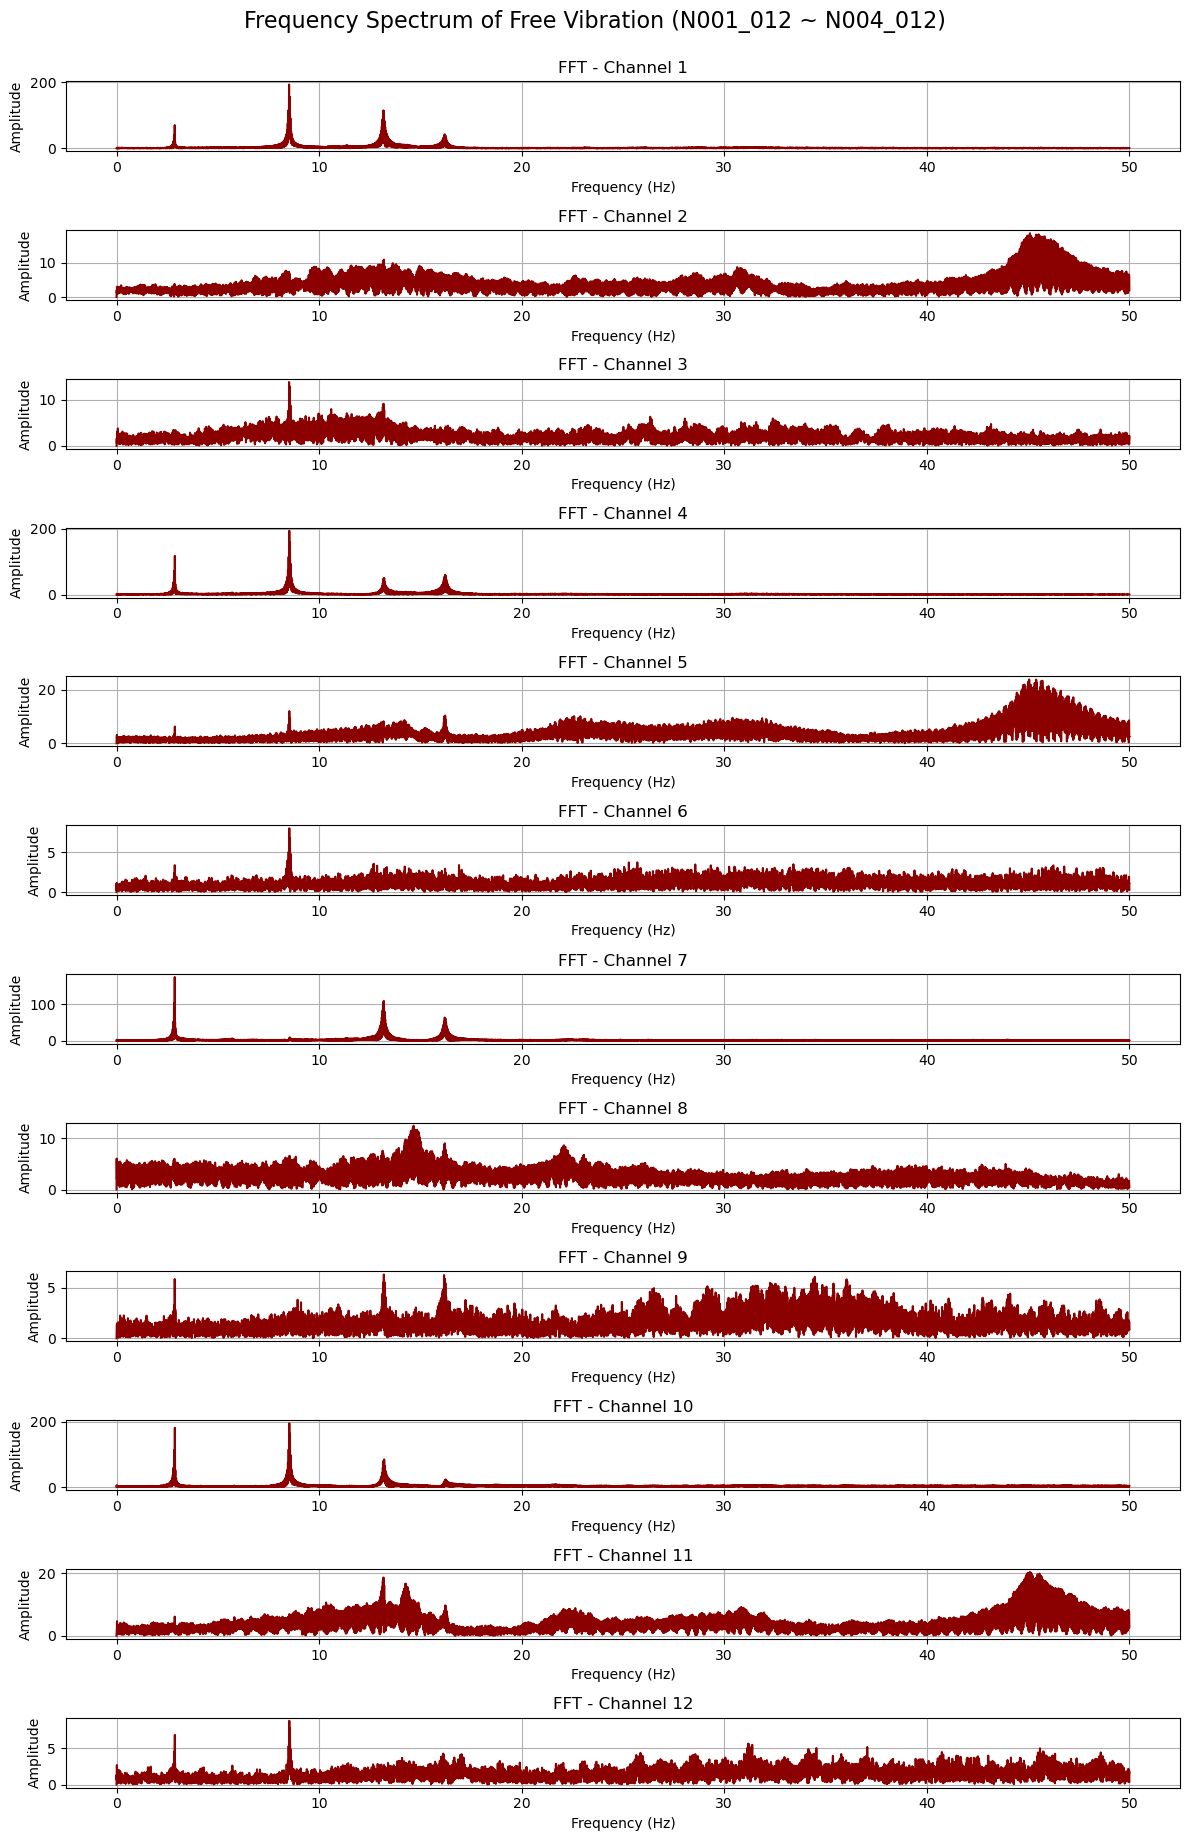

In [3]:
# === Step 3: Plot FFT of each channel ===
# Remove DC component
free_vib_wsn_zero_mean = free_vib_wsn - np.mean(free_vib_wsn, axis=0)

# Compute FFT
fs = 100  # Hz
n_samples = free_vib_wsn_zero_mean.shape[0]
freqs = np.fft.rfftfreq(n_samples, d=1/fs)
fft_data = [np.abs(np.fft.rfft(free_vib_wsn_zero_mean[:, i])) for i in range(n_channels)]

# Plot FFTs
plt.figure(figsize=(12, 18))
for i in range(n_channels):
    plt.subplot(12, 1, i + 1)
    plt.plot(freqs, fft_data[i], color='darkred')
    plt.title(f"FFT - Channel {i+1}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Frequency Spectrum of Free Vibration (N001_012 ~ N004_012)", fontsize=16, y=1.02)
plt.show()
